[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/03_calibration_and_decisions.ipynb)

# 3 · When should you believe a probability?

**Path:** Applied probability  
**Before you start:** Lesson 01; percentages; basic Python for the experiments

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

When a model says 80%, compare many such predictions with what really happened. Then choose actions using the cost of mistakes, not certainty alone.

**Your first pass:** Sections 1–4 are the core lesson. Temperature fitting, bootstrap intervals, and review costs are optional extensions.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **Calibration** | Whether stated probabilities match outcome frequencies across many cases. |
| **Coverage** | The fraction of cases the policy handles automatically. |
| **Review** | An alternative action for cases that should not be automated. |

## Goal
Separate **classification accuracy**, **calibration**, and **the decision your application takes**.
An 80% prediction means that comparable predictions should come true about 80% of the time,
not that this one is guaranteed. TypeSafe describes calibration as a training goal;
we do not measure its model here. [System One](https://docs.typesafe.ai/concepts/system-one).

## Setup
The following data are synthetic. Because we know how they are generated, we can construct an
oracle predictor and compare it with a deliberately overconfident version.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
REQUIRED_FILES = ("src/lab_core.py", "src/tutorial_utils.py", "data/tickets.json")
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if all((p / name).is_file() for name in REQUIRED_FILES)), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if COURSE_ROOT.exists() and not all((COURSE_ROOT / name).is_file() for name in REQUIRED_FILES):
            raise FileNotFoundError("The cached Colab course is incomplete. Start a fresh runtime and run all again.")
        if not COURSE_ROOT.exists():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
from tutorial_utils import setup, show_figure, table, BLUE, ORANGE, GREY
setup()

## Begin with ten outcomes

Imagine ten cases, each predicted to be yes with probability 0.80. We invent eight yes outcomes
and two no outcomes. The predicted frequency is 80%; the observed frequency is 8 ÷ 10 = 80%.

![Eight yes circles and two no crosses illustrate ten outcomes. The observed frequency is 8/10, or 80%. One group does not establish calibration.](../assets/calibration-counts.svg)

That is agreement **for this one constructed group**. It does not establish calibration across
other probabilities or future data. The larger experiment below shows why many cases and clear
denominators matter.

In [2]:
warmup_predictions = np.full(10, 0.80)
warmup_outcomes = np.array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0])
table(['Cases', 'Mean predicted yes probability', 'Observed yes outcomes', 'Observed yes frequency'],
      [[len(warmup_outcomes), f'{warmup_predictions.mean():.0%}',
        f'{warmup_outcomes.sum()} of {len(warmup_outcomes)}', f'{warmup_outcomes.mean():.0%}']])

Cases,Mean predicted yes probability,Observed yes outcomes,Observed yes frequency
10,80%,8 of 10,80%


**Predict a change:** if just one yes changes to no, the observed frequency is 70%.
That finite-group mismatch alone does not prove a model is miscalibrated. Read the reliability
diagram below as a pattern across bins, while keeping their sample sizes in view.

## Steps
### 1. Generate outcomes with known probabilities
For each fictional case draw a probability $p$, then a yes/no outcome with that chance of “yes.”
Our oracle reports $p$. The overconfident predictor multiplies log-odds by three, pushing values
toward 0 and 1 while preserving which side of 0.5 they lie on.

In [3]:
rng = np.random.default_rng(2026)
n = 12000
p_true = rng.uniform(0.03, 0.97, n)
y = rng.binomial(1, p_true)
log_odds = np.log(p_true / (1 - p_true))
p_overconfident = 1 / (1 + np.exp(-3 * log_odds))

def metrics(p):
    return ((p >= 0.5) == y).mean(), ((p - y) ** 2).mean()

table(['Predictor', 'Accuracy at 0.5', 'Brier score (lower is better)'],
      [(name, f'{metrics(p)[0]:.3f}', f'{metrics(p)[1]:.3f}')
       for name, p in [('Oracle', p_true), ('Overconfident', p_overconfident)]])

Predictor,Accuracy at 0.5,Brier score (lower is better)
Oracle,0.745,0.171
Overconfident,0.745,0.195


### 2. Read a reliability diagram
Group predictions into probability bins. Compare their mean predicted probability with their
observed fraction of positive outcomes. Perfect population calibration follows the diagonal;
finite samples still fluctuate. The Brier score is the mean of $(p-y)^2$. It evaluates overall
probabilistic prediction quality, including calibration and discrimination, rather than calibration alone.

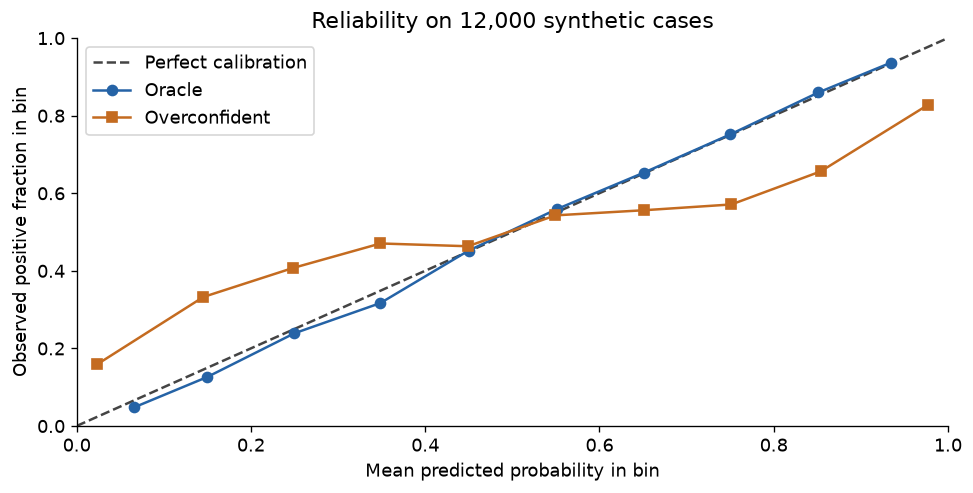

Oracle bin mean,Observed positive rate,Cases
0.07,0.05,820
0.15,0.13,1276
0.25,0.24,1273
0.35,0.32,1298
0.45,0.45,1277
0.55,0.56,1280
0.65,0.65,1270
0.75,0.75,1291
0.85,0.86,1253
0.93,0.94,962


In [4]:
def reliability(p, outcomes, bins=10):
    bucket = np.minimum((p * bins).astype(int), bins - 1)
    rows = []
    for k in range(bins):
        mask = bucket == k
        if mask.any():
            rows.append((p[mask].mean(), outcomes[mask].mean(), mask.sum()))
    return np.array(rows)

fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], '--', color=GREY, label='Perfect calibration')
for label, p, color, marker in [('Oracle', p_true, BLUE, 'o'),
                                ('Overconfident', p_overconfident, ORANGE, 's')]:
    points = reliability(p, y)
    ax.plot(points[:, 0], points[:, 1], marker=marker, color=color, label=label)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='Mean predicted probability in bin',
       ylabel='Observed positive fraction in bin', title='Reliability on 12,000 synthetic cases')
ax.legend()
show_figure('03_reliability')
table(['Oracle bin mean', 'Observed positive rate', 'Cases'],
      [(f'{a:.2f}', f'{b:.2f}', int(c)) for a, b, c in reliability(p_true, y)])

The two predictors have identical class decisions at 0.5. Their probability quality differs.
At high predicted probabilities, the overconfident curve falls below the diagonal: fewer positives
occur than promised. The bin counts above make the denominators visible; these are descriptive
estimates, with no confidence intervals shown.

### 3. Derive a threshold from the consequences
Suppose a false positive costs 4 units and a false negative costs 1 unit; correct actions cost zero.
Act “yes” when its expected cost is smaller:
$$(1-p)C_{FP}<pC_{FN}\quad\Longrightarrow\quad p>\frac{C_{FP}}{C_{FP}+C_{FN}}.$$
This assumes probabilities are appropriate for the current population and the costs describe the task.
It is not a general threshold for Jev's separate `confidence` field.

In [5]:
false_positive_cost, false_negative_cost = 4, 1
threshold = false_positive_cost / (false_positive_cost + false_negative_cost)

def average_cost(p, cutoff):
    action = p > cutoff
    return np.mean(false_positive_cost * (action & (y == 0))
                   + false_negative_cost * (~action & (y == 1)))

print(f'Cost-derived threshold: {threshold:.2f}')
table(['Probability source', 'Threshold', 'Observed cost per case'],
      [(name, t, f'{average_cost(p, t):.3f}')
       for name, p in [('Oracle', p_true), ('Overconfident', p_overconfident)]
       for t in [0.5, threshold]])

Cost-derived threshold: 0.80


Probability source,Threshold,Observed cost per case
Oracle,0.5,0.646
Oracle,0.8,0.413
Overconfident,0.5,0.646
Overconfident,0.8,0.500


### 4. Trade automation coverage for review
For this binary example define **maximum outcome probability** as $\max(p,1-p)$.
Only automate cases above a selected cutoff; review the rest. This is our own statistic, **not Jev's
confidence formula**. We report the error rate only among automated cases and the fraction automated.

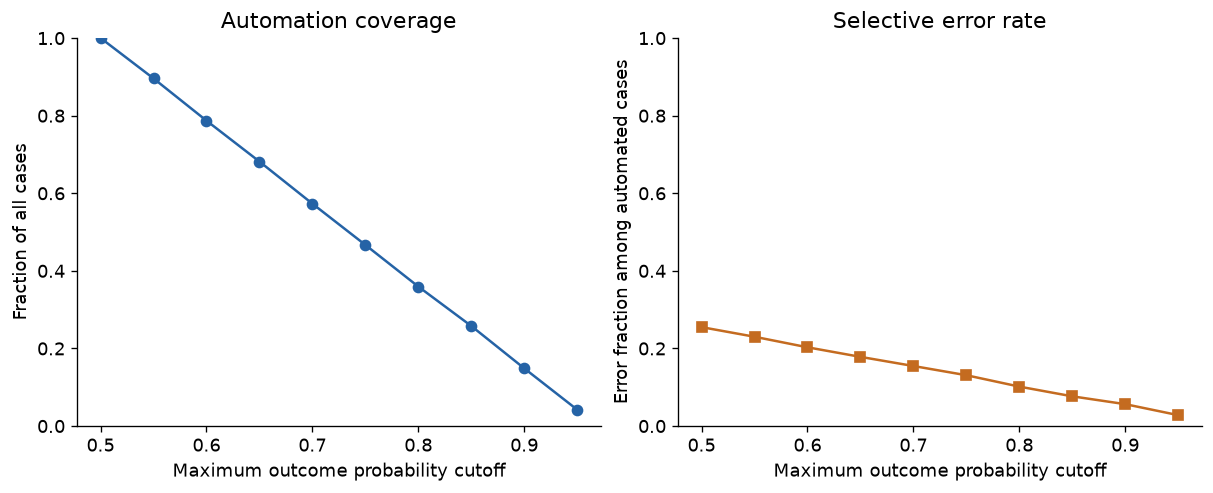

In [6]:
max_probability = np.maximum(p_true, 1 - p_true)
cutoffs = np.linspace(0.50, 0.95, 10)
coverage, error = [], []
for cutoff in cutoffs:
    automatic = max_probability >= cutoff
    coverage.append(automatic.mean())
    error.append(((p_true[automatic] >= 0.5) != y[automatic]).mean()
                 if automatic.any() else np.nan)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(cutoffs, coverage, 'o-', color=BLUE)
axes[1].plot(cutoffs, error, 's-', color=ORANGE)
for ax in axes:
    ax.set(xlabel='Maximum outcome probability cutoff', ylim=(0, 1))
axes[0].set(ylabel='Fraction of all cases', title='Automation coverage')
axes[1].set(ylabel='Error fraction among automated cases', title='Selective error rate')
show_figure('03_coverage_error')

Higher cutoffs reduce coverage here. The error rate improves in this constructed population,
but that behavior is not guaranteed under distribution shift or miscalibration.
Review cost and reviewer accuracy are omitted from this illustration.

> **Optional deeper practice.** You can stop reading here on your first pass. If you run the notebook, use Run All so the later checks still have their inputs.

### 5. Repair overconfidence using a separate calibration set
So far we compared known distributions. Now pretend we only see the overconfident logits and labels.
Use the **first 6,000 cases to fit temperature** and reserve the remaining 6,000 for evaluation.
No weights are trained in this experiment. A trained model would additionally need its own training set.

We select $T$ by minimizing binary log loss on the calibration split. Temperature scaling is a
post-processing method studied by [Guo et al. (2017)](https://proceedings.mlr.press/v70/guo17a.html).
It is not RLCD and not a Jev API parameter. A positive $T$ preserves the class ranking.

Validation-selected temperature: 2.784


Held-out predictor,Brier score,Accuracy
Before scaling,0.1964,0.741
After scaling,0.1719,0.741


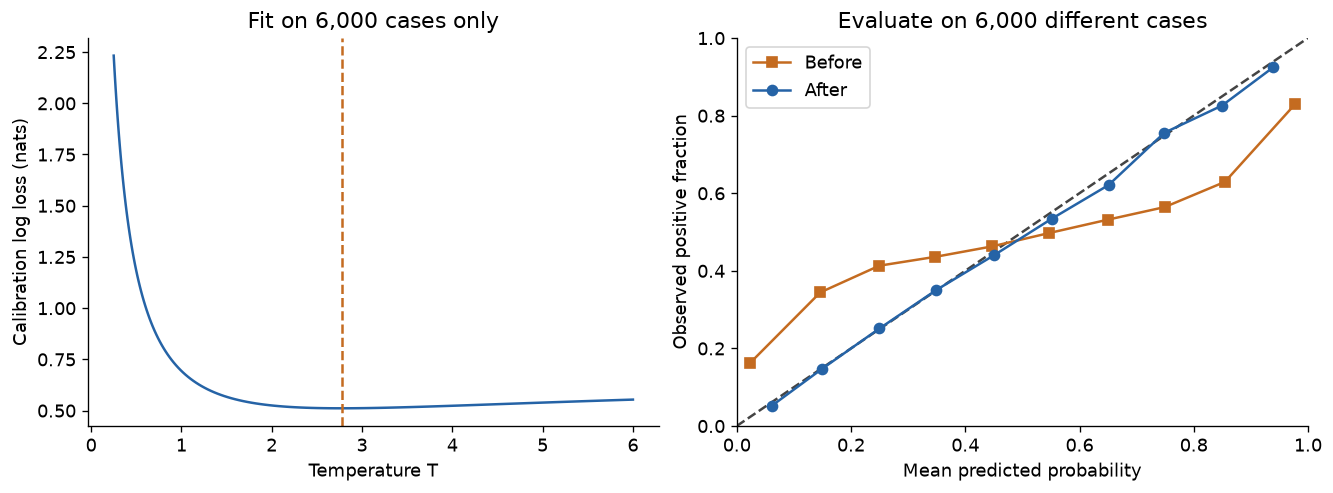

In [7]:
from lab_core import softmax as categorical_softmax, nll
calibration_ids = np.arange(6000)
evaluation_ids = np.arange(6000, n)
raw_logits = np.column_stack([np.zeros(n), 3 * log_odds])
temperatures = np.geomspace(.25, 6, 121)
calibration_losses = np.array([nll(categorical_softmax(raw_logits[calibration_ids], t), y[calibration_ids])
                              for t in temperatures])
fitted_temperature = temperatures[calibration_losses.argmin()]
fixed = categorical_softmax(raw_logits[evaluation_ids], fitted_temperature)[:, 1]
before = p_overconfident[evaluation_ids]
y_eval = y[evaluation_ids]
print(f'Validation-selected temperature: {fitted_temperature:.3f}')
table(['Held-out predictor', 'Brier score', 'Accuracy'], [
    (label, f'{np.mean((p-y_eval)**2):.4f}', f'{np.mean((p>=.5)==y_eval):.3f}')
    for label, p in [('Before scaling', before), ('After scaling', fixed)]])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(temperatures, calibration_losses, color=BLUE)
axes[0].axvline(fitted_temperature, color=ORANGE, linestyle='--')
axes[0].set(xlabel='Temperature T', ylabel='Calibration log loss (nats)', title='Fit on 6,000 cases only')
axes[1].plot([0, 1], [0, 1], '--', color=GREY)
for label, pp, col, marker in [('Before', before, ORANGE, 's'), ('After', fixed, BLUE, 'o')]:
    points = reliability(pp, y_eval)
    axes[1].plot(points[:, 0], points[:, 1], marker=marker, color=col, label=label)
axes[1].set(xlabel='Mean predicted probability', ylabel='Observed positive fraction',
            title='Evaluate on 6,000 different cases', xlim=(0,1), ylim=(0,1))
axes[1].legend()
show_figure('03_temperature_fit')
assert np.array_equal(before >= .5, fixed >= .5)

The fitted temperature should be near 3 because we deliberately multiplied the true log-odds by 3.
This unusually clean repair is built into the experiment. Real miscalibration need not be fixable
with one parameter. Sparse bins and changing populations can also mislead a reliability diagram.

### 6. An uncertainty interval and a distribution shift
Estimate uncertainty in the held-out **mean Brier score** by resampling cases with replacement.
The 95% percentile bootstrap interval assumes the sampled cases are independent and representative.
It is not a probability interval for one model answer.

In [8]:
bootstrap_rng = np.random.default_rng(91)
squared_errors = (fixed - y_eval) ** 2
bootstrap_means = [squared_errors[bootstrap_rng.integers(0, len(y_eval), len(y_eval))].mean()
                   for _ in range(500)]
low, high = np.quantile(bootstrap_means, [.025, .975])
print(f'Held-out Brier = {squared_errors.mean():.4f}; 95% bootstrap interval [{low:.4f}, {high:.4f}]')

# Change the outcome relationship, while leaving the predictor unchanged.
shifted_true_p = 1 / (1 + np.exp(-(log_odds[evaluation_ids] + 1.5)))
shifted_y = bootstrap_rng.binomial(1, shifted_true_p)
print(f'Original positive rate: {y_eval.mean():.3f}; shifted positive rate: {shifted_y.mean():.3f}')
print(f'Brier after this synthetic shift: {np.mean((fixed-shifted_y)**2):.4f}')

Held-out Brier = 0.1719; 95% bootstrap interval [0.1668, 0.1771]
Original positive rate: 0.492; shifted positive rate: 0.749
Brier after this synthetic shift: 0.2138


### 7. Include the cost of review
If perfect review costs $C_R$ and correct automatic actions cost zero, compare three expected costs:
$C_{yes}=(1-p)C_{FP}$, $C_{no}=pC_{FN}$, and $C_{review}=C_R$.
Real reviewers also make mistakes; the flat review-cost assumption below is deliberately idealized.

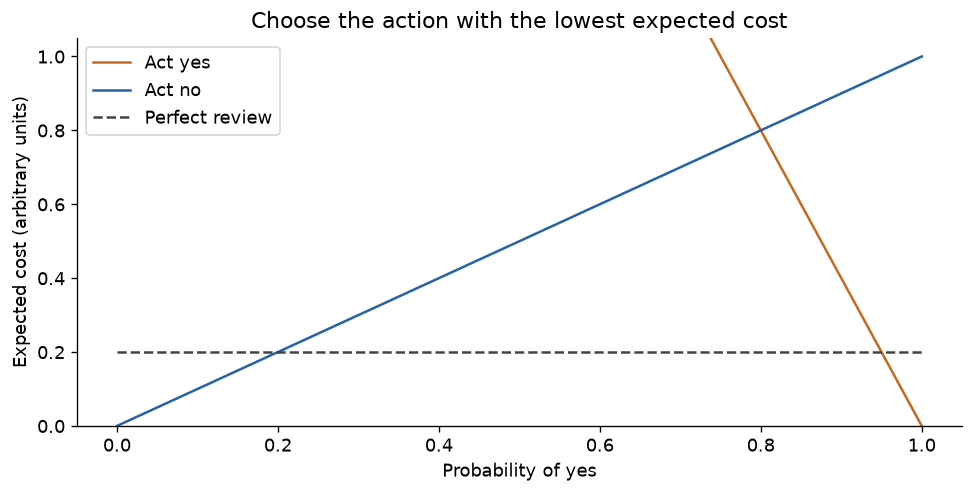

At p=0.5, cheapest action: review


In [9]:
probability_grid = np.linspace(0, 1, 301)
costs = np.column_stack([4*(1-probability_grid), probability_grid, np.full(301, .2)])
fig, ax = plt.subplots()
for i, (label, col, style) in enumerate(zip(['Act yes', 'Act no', 'Perfect review'],
                                         [ORANGE, BLUE, GREY], ['-', '-', '--'])):
    ax.plot(probability_grid, costs[:, i], color=col, linestyle=style, label=label)
ax.set(xlabel='Probability of yes', ylabel='Expected cost (arbitrary units)', ylim=(0, 1.05),
       title='Choose the action with the lowest expected cost')
ax.legend()
show_figure('03_review_cost')
print('At p=0.5, cheapest action:', ['yes', 'no', 'review'][costs[150].argmin()])

**Predict first — exercise 3:** With costs $C_{FP}=4$, $C_{FN}=1$, and $C_R=0.2$,
find the two probability boundaries between “no,” “review,” and “yes.”
What happens if review costs 0.8 instead? See the worked solution after attempting it.

## Checks

In [10]:
assert np.array_equal(p_true >= 0.5, p_overconfident >= 0.5)
assert metrics(p_true)[1] < metrics(p_overconfident)[1]
assert np.all(np.diff(coverage) <= 0)
assert average_cost(p_true, threshold) < average_cost(p_true, 0.5)
print('Accuracy equality, Brier comparison, coverage, and cost checks passed.')

Accuracy equality, Brier comparison, coverage, and cost checks passed.


## Next Steps
Change the false-positive cost to 9. Predict the threshold before running: 0.9.

For real Jev evaluation, collect labeled examples for your exact questions; tune on a validation set
and evaluate once on a separate test set. Track calibration, mistakes by category, coverage, latency,
and cost. Recheck after changing prompts, model version, or population. Do not infer real Jev
accuracy from this synthetic experiment. Continue to [workflows](04_workflows_and_related_models.ipynb).

## Take three ideas with you

- Accuracy measures correct labels; calibration compares probabilities with observed frequencies.
- Fit adjustments on separate data and check the result on held-out cases.
- Review and mistake costs change which action is best.

**You are ready to move on when:** You can distinguish accuracy from calibration and explain why a threshold depends on the task.

## Check your understanding

A well-calibrated model predicts yes with probability 0.8. Must this case be yes?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>No. Calibration is a pattern across many predictions. Roughly one in five comparable 0.8 predictions should be negative.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

If you are unsure where to go next, use [the course outline](../docs/COURSE.md).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)